## SAC Training Comparison — Analysis & Visualisation

This notebook analyzes SAC routing training logs exported as `comparison.csv` (generated by `backend/model training/sac_routing_v7.ipynb`).

**Default expected path**: `backend/models/sac_routing/comparison.csv`

It produces **episode-wise**, **epoch-wise**, and **agent-wise** plots using **pandas** and **seaborn**.


In [3]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)

sns.set_theme(style="whitegrid", context="talk")


def find_repo_root(start: Path) -> Path:
    """Walk upwards until we find a folder that looks like the repo root."""
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "backend").exists():
            return p
    return start


PROJECT_ROOT = find_repo_root(Path.cwd())
DEFAULT_CSV = PROJECT_ROOT / "backend" / "models" / "sac_routing" / "comparison.csv"

# You can override this if your CSV is elsewhere.
CSV_PATH = DEFAULT_CSV

print("CWD       =", Path.cwd().resolve())
print("ROOT      =", PROJECT_ROOT)
print("CSV_PATH  =", CSV_PATH)
print("Exists    =", CSV_PATH.exists())
if not CSV_PATH.exists():
    print(
        "\ncomparison.csv not found.\n"
        "Expected at: backend/models/sac_routing/comparison.csv\n"
        "If your CSV is elsewhere, set CSV_PATH to the correct file path and re-run."\
    )


CWD       = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\data generation
ROOT      = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning
CSV_PATH  = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\models\sac_routing\comparison.csv
Exists    = True


In [4]:
# Load + light cleaning

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"comparison.csv not found at {CSV_PATH}. "
        "Set CSV_PATH in the previous cell to the correct location."
    )

df = pd.read_csv(CSV_PATH)
print("rows:", len(df))
print("columns:", list(df.columns))

# Standardize dtypes where expected
int_cols = ["epoch", "ep_in_epoch", "global_ep", "agent", "reached_by_policy", "used_fallback", "policy_steps", "total_steps"]
for c in int_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        # Use plain numpy int64 when possible (seaborn/mpl can fail with pandas nullable Int64)
        if not df[c].isna().any():
            df[c] = df[c].astype("int64")
        else:
            df[c] = df[c].astype("Int64")

float_cols = ["astar_pred_min", "astar_nom_min", "astar_flood_min", "sac_time_min", "sac_reward"]
for c in float_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Plot-safe helper columns
if "agent" in df.columns:
    df["agent_label"] = df["agent"].astype("int64") if not df["agent"].isna().any() else df["agent"].astype("Int64")
    df["agent_label"] = df["agent_label"].astype(str)

if "global_ep" in df.columns:
    df["global_ep_num"] = df["global_ep"].astype("int64") if not df["global_ep"].isna().any() else pd.to_numeric(df["global_ep"], errors="coerce")

# Ensure stable sort for plots
sort_cols = [c for c in ["global_ep", "epoch", "ep_in_epoch", "agent"] if c in df.columns]
if sort_cols:
    df = df.sort_values(sort_cols).reset_index(drop=True)

df.head(10)


rows: 23220
columns: ['epoch', 'ep_in_epoch', 'global_ep', 'agent', 'src_name', 'dst_name', 'astar_pred_min', 'astar_nom_min', 'astar_flood_min', 'sac_time_min', 'reached_by_policy', 'used_fallback', 'fallback_reason', 'policy_steps', 'total_steps', 'sac_reward']


,epoch,ep_in_epoch,global_ep,agent,src_name,dst_name,astar_pred_min,astar_nom_min,astar_flood_min,sac_time_min,reached_by_policy,used_fallback,fallback_reason,policy_steps,total_steps,sac_reward
0,1,1,1,0,Jawahar Nagar,Pandurang Wadi,4.561414,4.269104,9.894468,9.835727,1,0,NaN,35,35,240.044781
1,1,1,1,1,Vibgyor High School,St Xaviers High School,4.846406,4.498603,10.121805,6.969933,1,0,NaN,37,37,289.310032
2,1,1,1,2,Unnat Nagar,Nirlon Knowledge Park,6.921502,6.455197,7.564098,9.769433,0,1,cycle,50,65,234.956208
3,1,1,1,3,Goregaon East,Unnat Nagar,4.669579,4.332778,10.540929,11.507326,0,1,cycle,10,20,231.748621
4,1,1,1,4,Pandurang Wadi,Motilal Nagar,5.518619,5.136123,10.011638,10.135373,1,0,NaN,37,37,309.183675
5,1,1,1,5,Royal Palms Estate,St Johns High School,12.837715,11.908803,29.223761,31.608047,0,1,cycle,31,40,115.180875
6,1,1,1,6,Nesco IT Park,Bangur Nagar,7.346113,6.859770,12.689328,13.439030,1,0,NaN,45,45,246.847854
7,1,1,1,7,St Johns High School,Goregaon East,3.592589,3.339981,8.254296,9.083378,0,1,cycle,14,36,198.509757
8,1,1,1,8,Lifeline Medicare Hospital,Vibgyor High School,3.772405,3.514349,3.592620,4.696809,1,0,NaN,37,37,326.605741
9,1,2,2,0,Jawahar Nagar,Pandurang Wadi,4.561414,4.269104,9.894468,14.733219,1,0,NaN,64,64,202.898490


In [5]:
# Derived metrics

def _safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)

if {"sac_time_min", "astar_flood_min"}.issubset(df.columns):
    df["improv_vs_flood_pct"] = (1 - _safe_div(df["sac_time_min"], df["astar_flood_min"])) * 100

if {"sac_time_min", "astar_nom_min"}.issubset(df.columns):
    df["improv_vs_nom_pct"] = (1 - _safe_div(df["sac_time_min"], df["astar_nom_min"])) * 100

if {"policy_steps", "total_steps"}.issubset(df.columns):
    df["policy_step_frac"] = _safe_div(df["policy_steps"], df["total_steps"]).clip(0, 1)

summary_cols = [
    c for c in [
        "epoch","global_ep","agent",
        "astar_nom_min","astar_flood_min","sac_time_min",
        "reached_by_policy","used_fallback","fallback_reason",
        "policy_steps","total_steps","sac_reward",
        "improv_vs_flood_pct","improv_vs_nom_pct","policy_step_frac",
    ]
    if c in df.columns
]

df[summary_cols].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
epoch,23220.0,<NA>,<NA>,<NA>,22.0,12.409941,1.0,11.0,22.0,33.0,43.0
global_ep,23220.0,<NA>,<NA>,<NA>,1290.5,744.797829,1.0,645.75,1290.5,1935.25,2580.0
agent,23220.0,<NA>,<NA>,<NA>,4.0,2.582044,0.0,2.0,4.0,6.0,8.0
astar_nom_min,23220.0,NaN,NaN,NaN,5.445976,3.567142,0.186082,3.013353,4.498603,6.455197,14.964123
astar_flood_min,23220.0,NaN,NaN,NaN,10.609156,7.031447,0.472337,5.885552,9.143389,13.060105,36.61819
sac_time_min,23220.0,NaN,NaN,NaN,10.395955,7.16432,0.472337,5.26293,8.89141,13.000006,44.247308
reached_by_policy,23220.0,<NA>,<NA>,<NA>,0.946339,0.225352,0.0,1.0,1.0,1.0,1.0
used_fallback,23220.0,<NA>,<NA>,<NA>,0.053661,0.225352,0.0,0.0,0.0,0.0,1.0
fallback_reason,1246,3,cycle,599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_steps,23220.0,<NA>,<NA>,<NA>,26.02907,13.14697,1.0,16.0,24.0,35.0,86.0


## Episode-wise trends

Plots vs `global_ep` to show how training evolved over time. If you have multiple agents, we use hue by `agent`.


TypeError: Cannot interpret 'Int64Dtype()' as a data type

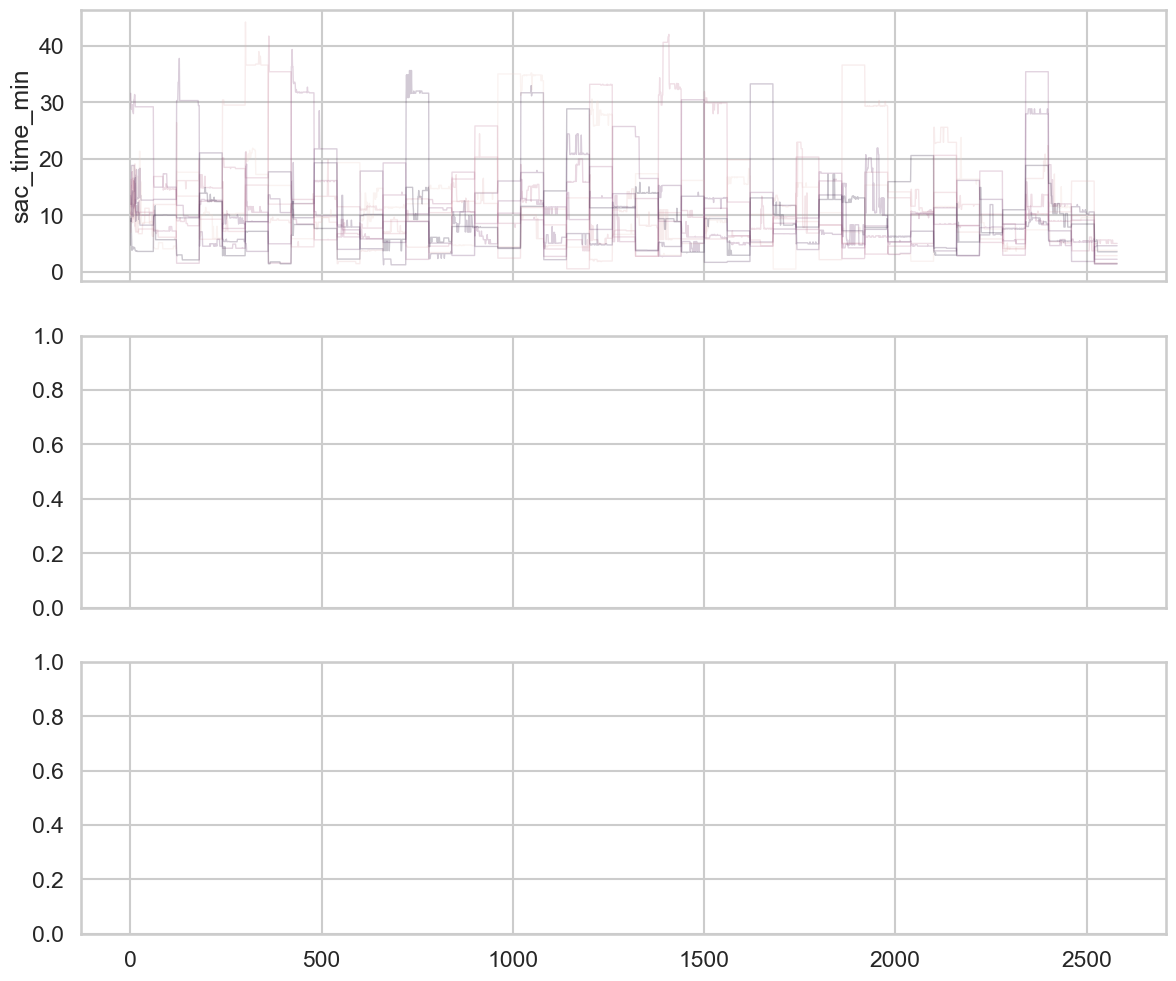

In [7]:
def rolling_mean(s: pd.Series, win: int = 15):
    return s.rolling(win, min_periods=max(3, win // 3)).mean()

xcol = "global_ep" if "global_ep" in df.columns else ("ep_in_epoch" if "ep_in_epoch" in df.columns else None)
hue = "agent" if "agent" in df.columns else None

plot_cols = [c for c in ["sac_time_min", "astar_flood_min", "astar_nom_min"] if c in df.columns]
if xcol and plot_cols:
    mdf = df[[xcol] + ([hue] if hue else []) + plot_cols].copy()
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 4 * len(plot_cols)), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]

    for ax, y in zip(axes, plot_cols):
        sns.lineplot(data=mdf, x=xcol, y=y, hue=hue, estimator=None, alpha=0.25, linewidth=1, ax=ax)
        if hue:
            for aid, g in mdf.groupby(hue):
                ax.plot(g[xcol], rolling_mean(g[y]), linewidth=2.2, label=f"ag{aid} (roll)")
        else:
            ax.plot(mdf[xcol], rolling_mean(mdf[y]), linewidth=2.2, label="roll")

        ax.set_title(y)
        ax.legend(loc="best", fontsize=9)

    plt.tight_layout()
else:
    print("Missing columns for episode-wise time plots.")


In [ ]:
# Reward + policy reach / fallback over episodes

if xcol and "sac_reward" in df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.lineplot(data=df, x=xcol, y="sac_reward", hue=hue, estimator=None, alpha=0.25, linewidth=1, ax=ax)
    if hue:
        for aid, g in df.groupby(hue):
            ax.plot(g[xcol], rolling_mean(g["sac_reward"]), linewidth=2.2, label=f"ag{aid} (roll)")
    else:
        ax.plot(df[xcol], rolling_mean(df["sac_reward"]), linewidth=2.2, label="roll")
    ax.set_title("SAC reward vs episode")
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()

rate_cols = [c for c in ["reached_by_policy", "used_fallback"] if c in df.columns]
if xcol and rate_cols:
    rdf = df[[xcol] + ([hue] if hue else []) + rate_cols].copy()
    for c in rate_cols:
        rdf[c] = pd.to_numeric(rdf[c], errors="coerce")

    fig, axes = plt.subplots(len(rate_cols), 1, figsize=(14, 4 * len(rate_cols)), sharex=True)
    if len(rate_cols) == 1:
        axes = [axes]

    for ax, y in zip(axes, rate_cols):
        # raw dots/lines are too noisy; show rolling mean only
        if hue:
            for aid, g in rdf.groupby(hue):
                ax.plot(g[xcol], rolling_mean(g[y], 25), linewidth=2.4, label=f"ag{aid} (roll25)")
        else:
            ax.plot(rdf[xcol], rolling_mean(rdf[y], 25), linewidth=2.4, label="roll25")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{y} (rolling mean)")
        ax.legend(loc="best", fontsize=9)

    plt.tight_layout()


## Epoch-wise analysis

Group by `epoch` and look at mean/median time, improvement vs baselines, and policy reach/fallback rates.


In [ ]:
if "epoch" in df.columns:
    agg = {
        "sac_time_min": ["mean", "median"],
        "astar_flood_min": ["mean", "median"],
        "astar_nom_min": ["mean", "median"],
        "sac_reward": ["mean", "median"],
        "reached_by_policy": ["mean"],
        "used_fallback": ["mean"],
        "policy_steps": ["mean"],
        "total_steps": ["mean"],
        "improv_vs_flood_pct": ["mean", "median"],
        "improv_vs_nom_pct": ["mean", "median"],
    }
    agg = {k: v for k, v in agg.items() if k in df.columns}

    edf = df.groupby("epoch", dropna=False).agg(agg)
    edf.columns = ["_".join(col).strip("_") for col in edf.columns.to_flat_index()]
    edf = edf.reset_index()
    display(edf)

    # Plot a few key epoch metrics
    key_epoch = [c for c in [
        "sac_time_min_mean",
        "astar_flood_min_mean",
        "astar_nom_min_mean",
        "improv_vs_flood_pct_mean",
        "reached_by_policy_mean",
        "used_fallback_mean",
        "sac_reward_mean",
    ] if c in edf.columns]

    if key_epoch:
        fig, axes = plt.subplots(len(key_epoch), 1, figsize=(14, 4 * len(key_epoch)), sharex=True)
        if len(key_epoch) == 1:
            axes = [axes]
        for ax, y in zip(axes, key_epoch):
            sns.lineplot(data=edf, x="epoch", y=y, marker="o", ax=ax)
            ax.set_title(y)
            if y.endswith("_mean") and ("reached_by_policy" in y or "used_fallback" in y):
                ax.set_ylim(-0.05, 1.05)
        plt.tight_layout()
else:
    print("No 'epoch' column found.")


## Agent-wise analysis

Compare agents on mean SAC time vs baselines, improvement distribution, and policy reach/fallback rates.


In [ ]:
if "agent" in df.columns:
    gcols = [c for c in [
        "sac_time_min",
        "astar_flood_min",
        "astar_nom_min",
        "improv_vs_flood_pct",
        "improv_vs_nom_pct",
        "reached_by_policy",
        "used_fallback",
        "policy_step_frac",
        "total_steps",
        "sac_reward",
    ] if c in df.columns]

    adf = df.groupby("agent")[gcols].mean(numeric_only=True).reset_index()
    display(adf.sort_values("agent"))

    # Bar: mean times by agent
    time_cols = [c for c in ["sac_time_min", "astar_flood_min", "astar_nom_min"] if c in df.columns]
    if time_cols:
        tlong = df.melt(id_vars=["agent"], value_vars=time_cols, var_name="metric", value_name="minutes")
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.barplot(data=tlong, x="agent", y="minutes", hue="metric", errorbar="se", ax=ax)
        ax.set_title("Mean travel time by agent (±SE)")
        plt.tight_layout()

    # Distribution of improvement
    if "improv_vs_flood_pct" in df.columns:
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.boxplot(data=df, x="agent", y="improv_vs_flood_pct", ax=ax)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title("Improvement vs flooded A* (%) — distribution by agent")
        plt.tight_layout()

    # Reach / fallback rates
    rate_cols = [c for c in ["reached_by_policy", "used_fallback"] if c in df.columns]
    if rate_cols:
        rdf = df.groupby("agent")[rate_cols].mean(numeric_only=True).reset_index()
        rlong = rdf.melt(id_vars=["agent"], var_name="metric", value_name="rate")
        fig, ax = plt.subplots(figsize=(14, 5))
        sns.barplot(data=rlong, x="agent", y="rate", hue="metric", ax=ax)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title("Policy reach / fallback rates by agent")
        plt.tight_layout()
else:
    print("No 'agent' column found.")


## Fallback reasons + quick diagnostics

Useful when SAC doesn't reach via policy and the environment falls back.


In [ ]:
if "fallback_reason" in df.columns:
    fr = df["fallback_reason"].fillna("").astype(str)
    fr = fr.where(fr.str.len() > 0, other="(none)")
    top = fr.value_counts().head(20).reset_index()
    top.columns = ["fallback_reason", "count"]
    display(top)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=top, y="fallback_reason", x="count", ax=ax)
    ax.set_title("Top fallback reasons")
    plt.tight_layout()

# Numeric correlation heatmap
num = df.select_dtypes(include=["number", "integer", "floating"]).copy()
if len(num.columns) >= 3:
    corr = num.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
    ax.set_title("Numeric correlation")
    plt.tight_layout()
